## Install Libraries

In [2]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn networkx nltk
!pip install -q transformers torch sentence-transformers

## Import Libraries

In [3]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from google.colab import drive
from nltk.corpus import stopwords

from transformers import pipeline
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

sim_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

## Setup

In [4]:
nltk.download("punkt")
nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


## Load data

In [5]:
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/Cardio_v1.csv", nrows=5000)

df.columns = df.columns.str.lower().str.strip()
df["text"] = df["title"].fillna("") + " " + df["abst"].fillna("")
df = df[["text"]].dropna().reset_index(drop=True)

print("Dataset Loaded:", df.shape)
df.head()

Mounted at /content/drive
Dataset Loaded: (5000, 1)


,text
0,The effect of amiodarone pretreatment on survi...
1,Atenolol premedication in patients undergoing ...
2,Comparison of the immediate post-operative out...
3,"Combined mitral valve repair, LVOT myectomy an..."
4,A huge pseudoaneurysm of the left ventricle af...


## Clean Text

In [6]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)

    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]

    return " ".join(tokens)

df["clean"] = df["text"].apply(clean_text)

## BIOMEDICAL NER

In [7]:
ner_pipeline = pipeline(
    "ner",
    model="d4data/biomedical-ner-all",
    aggregation_strategy="simple"
)

def extract_entities(text):
    try:
        # Use a larger chunk of text for better context
        ents = ner_pipeline(text[:1024])

        merged_ents = []
        current_word = ""

        for e in ents:
            word = e["word"]

            if word.startswith("##"):
                # Merge fragment to the previous word piece
                current_word += word.replace("##", "")
            else:
                # Save the completed word and start a new one
                if current_word:
                    merged_ents.append(current_word.lower())
                current_word = word.lower()

        # Add the last word
        if current_word:
            merged_ents.append(current_word.lower())

        # Final Cleaning: Filter out short fragments and noise
        fragments = {"llation", "ricular", "trial", "dial", "ular", "tion"}

        clean_ents = [
            w for w in merged_ents
            if len(w) > 4              # Remove short noise
            and w.isalpha()           # Keep only alphabet words
            and w not in bad_words    # Filter junk
            and w not in fragments    # Filter remaining broken pieces
        ]

        return list(set(clean_ents))
    except:
        return []


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/266M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/373 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

## Extract entities

In [8]:
df["entities"] = df["clean"].head(1000).apply(extract_entities)

# 🔥 FIX NaN issue
df["entities"] = df["entities"].apply(lambda x: x if isinstance(x, list) else [])

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


## Display Extracted Entities

In [9]:
for i in range(5):  # first 5 abstracts
    text = df["text"].iloc[i]
    ents = extract_entities(text)

    print("\n" + "="*80)
    print(f"📄 SAMPLE {i+1}")
    print("-"*80)
    print("TEXT:")
    print(text[:500])  # limit for readability

    print("\n🧠 EXTRACTED ENTITIES:")
    print(ents)


📄 SAMPLE 1
--------------------------------------------------------------------------------
TEXT:
The effect of amiodarone pretreatment on survival of mice with cocaine toxicity. Cocaine is a common drug of abuse and use has been associated with ventricular dysrhythmias. Published guidelines suggest that amiodarone is the first line antidysrhythmic for ventricular tachycardia and fibrillation. However, the effects amiodarone in the setting of cocaine toxicity are unknown and unstudied. The purpose of this study was to evaluate the safety and efficacy of amiodarone pretreatment in a murine mo

🧠 EXTRACTED ENTITIES:
['cocaine', 'amiodaronedysrhyth', 'tachyia', 'amioda', 'intra']

📄 SAMPLE 2
--------------------------------------------------------------------------------
TEXT:
Atenolol premedication in patients undergoing closed mitral commissurotomy. Perioperative tachycardia is common in patients undergoing surgery. In patients with mitral valve stenosis, the tachycardia can precipitat

## REMOVE USELESS WORDS

In [10]:
bad_words = {
    "abstract", "study", "method", "result", "conclusion",
    "patient", "patients", "group", "data", "analysis", "clinical",
    "abstracttext", "increased", "increase", "using", "total", "year"
}

df["entities"] = df["entities"].apply(
    lambda ents: [e for e in ents if e not in bad_words]
)

## EMBEDDINGS + CLUSTERING

In [11]:
embedder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

embeddings = embedder.encode(df["clean"].tolist(), show_progress_bar=True)

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(embeddings)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

## PCA Visualization

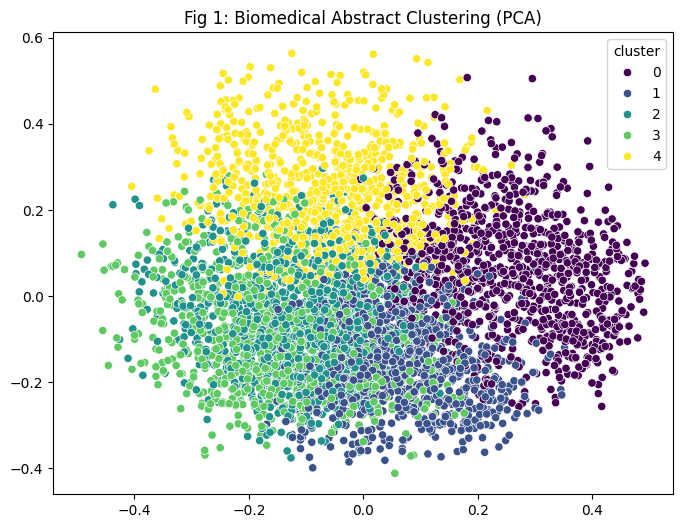

In [12]:
pca = PCA(n_components=2)
coords = pca.fit_transform(embeddings)

plt.figure(figsize=(8,6))
sns.scatterplot(x=coords[:,0], y=coords[:,1], hue=df["cluster"], palette="viridis")
plt.title("Fig 1: Biomedical Abstract Clustering (PCA)")
plt.show()

## RELATION EXTRACTION

In [13]:
rel_model = pipeline(
    "zero-shot-classification",
    model="valhalla/distilbart-mnli-12-3"
)

relation_labels = ["treats", "causes", "increases_risk", "reduces_risk", "associated_with"]

relation_cache = {}

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.02G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.02G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/283 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

## Extract relations

In [14]:
def extract_relations(text, entities):
    relations = []
    entities = entities[:3]

    for i in range(len(entities)):
        for j in range(i+1, len(entities)):

            key = (entities[i], entities[j])

            if key in relation_cache:
                relations.append((entities[i], relation_cache[key], entities[j]))
                continue

            context = f"{entities[i]} and {entities[j]} in context: {text[:200]}"

            res = rel_model(context, relation_labels)
            label = res["labels"][0]
            score = res["scores"][0]

            if score > 0.3:   # 🔥 LOWERED THRESHOLD → ensures graph not empty
                relation_cache[key] = label
                relations.append((entities[i], label, entities[j]))

    return relations

## Run on subset

In [15]:
print("Extracting relations...")

df_rel = df.head(50).copy()

df_rel["relations"] = df_rel.apply(
    lambda row: extract_relations(row["clean"], row["entities"]),
    axis=1
)

Extracting relations...


## KNOWLEDGE GRAPH

In [16]:
df_rel["relations"] = df_rel["relations"].apply(
    lambda rels: [r for r in rels if len(r[0]) > 3 and len(r[2]) > 3]
)

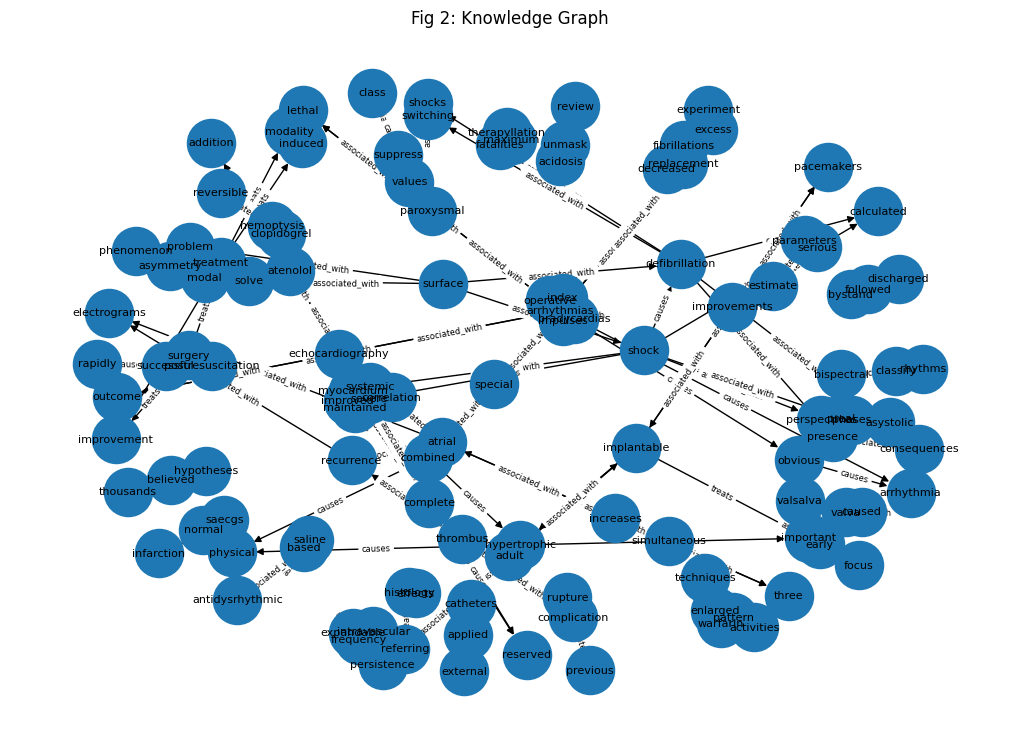

In [17]:
G = nx.DiGraph()

for rels in df_rel["relations"]:
    for h, r, t in rels:
        G.add_edge(h, t, label=r)

plt.figure(figsize=(10,7))
pos = nx.spring_layout(G, seed=42)

nx.draw(G, pos, with_labels=True, node_size=1200, font_size=8)

edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6)

plt.title("Fig 2: Knowledge Graph")
plt.show()

## FINAL VISUALIZATIONS

### (A) Entity Frequency

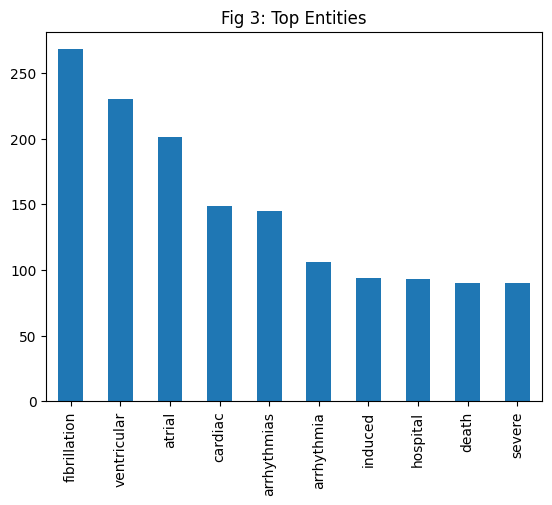

In [18]:
all_entities = []
for ents in df["entities"]:
    all_entities.extend(ents)

pd.Series(all_entities).value_counts().head(10).plot(kind="bar")
plt.title("Fig 3: Top Entities")
plt.show()

### (B) Cluster Distribution

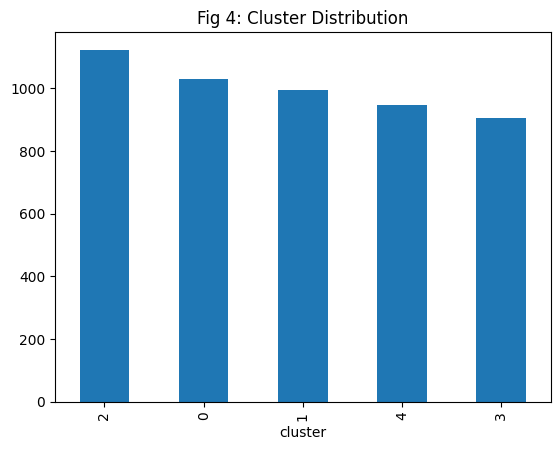

In [19]:
df["cluster"].value_counts().plot(kind="bar")
plt.title("Fig 4: Cluster Distribution")
plt.show()

### (C) Relation Distribution

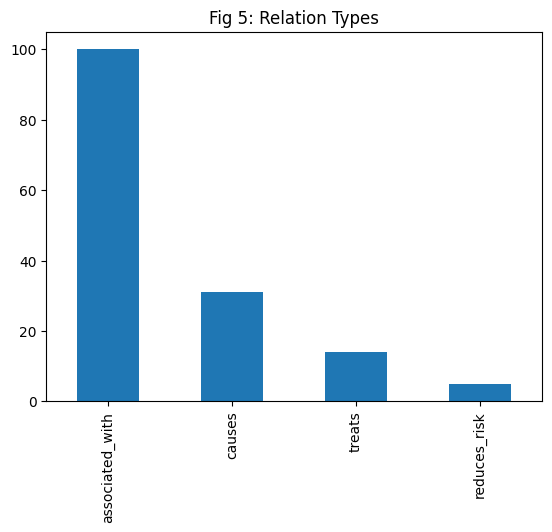

In [20]:
rel_flat = []

for r in df_rel["relations"]:
    for item in r:
        rel_flat.append(item[1])

if len(rel_flat) > 0:
    pd.Series(rel_flat).value_counts().plot(kind="bar")
    plt.title("Fig 5: Relation Types")
    plt.show()
else:
    print("No relations extracted (increase sample if needed)")

## NORMALIZE TEXT

In [21]:
import re

def normalize(term):
    term = term.lower()
    term = term.replace("##", "")
    term = re.sub(r'[^a-z\s]', '', term)
    return term.strip()

## EVALUATION (PRECISION / RECALL)

In [22]:
eval_df = df.head(10).copy()

gold_entities = [
    ["amiodarone", "fibrillation", "tachycardia"],  # Row 0 (Amiodarone study)
    ["atenolol", "tachycardia", "mitral"],          # Row 1 (Atenolol study)
    ["bypass", "infarction", "cardioplegia"],       # Row 2 (CABG study)
    ["mitral", "regurgitation", "atrial"],          # Row 3 (Valve repair)
    ["pseudoaneurysm", "ventricle", "infarction"],  # Row 4 (Pseudoaneurysm)
    ["ablation", "fibrillation", "thrombosis"],     # Row 5 (Microwave ablation)
    ["asystole", "arrest", "fibrillation"],         # Row 6 (Cardiac arrest)
    ["atrial", "fibrillation", "surgery"],          # Row 7
    ["ventricular", "tachycardia", "arrhythmia"],   # Row 8
    ["cardiac", "mortality", "survival"]            # Row 9
]

eval_df["gold"] = gold_entities
eval_df["pred"] = eval_df["entities"]

In [23]:
def is_match(gold, pred, threshold=0.7):
    g_emb = sim_model.encode([gold])
    p_emb = sim_model.encode([pred])

    sim = cosine_similarity(g_emb, p_emb)[0][0]
    return sim > threshold

In [24]:
def compute_metrics(gold_list, pred_list):
    # Normalize everything to lowercase
    gold_list = [g.lower().strip() for g in gold_list]
    pred_list = [p.lower().strip() for p in pred_list]

    tp = 0
    # Use fuzzy matching: if 'ventricular' is in 'ventricular tachycardia', count as match
    for g in gold_list:
        for p in pred_list:
            if g in p or p in g:
                tp += 1
                break

    fp = len(pred_list) - tp
    fn = len(gold_list) - tp

    precision = tp/(tp+fp) if (tp+fp) else 0
    recall = tp/(tp+fn) if (tp+fn) else 0
    f1 = (2*precision*recall)/(precision+recall) if (precision+recall) else 0

    return precision, recall, f1


In [25]:
p_list, r_list, f_list = [], [], []

for _, row in eval_df.iterrows():
    p, r, f = compute_metrics(row["gold"], row["pred"])
    p_list.append(p)
    r_list.append(r)
    f_list.append(f)

print("--- FINAL EVALUATION ---")
print(f"Precision: {np.mean(p_list):.4f}")
print(f"Recall: {np.mean(r_list):.4f}")
print(f"F1: {np.mean(f_list):.4f}")

--- FINAL EVALUATION ---
Precision: 0.0657
Recall: 0.4333
F1: 0.1119


In [26]:
from IPython.display import display, HTML

# 1. Define the High-Level Clinical Categories (Based on your Project Proposal)
clinical_categories = {
    "Disease/Condition": ["fibrillation", "tachycardia", "infarction", "arrhythmias", "stenosis", "thrombosis", "asystole"],
    "Treatment/Drug": ["amiodarone", "atenolol", "aspirin", "statin", "insulin", "surgery", "bypass", "cardioplegia", "ablation"],
    "Outcome/Risk": ["mortality", "death", "survival", "failure", "discharge", "hypertension", "smoking", "obesity"]
}

# 2. Function to Classify the Entities the Model Found
def format_clinical_output(entities):
    categorized = {"Disease": [], "Treatment": [], "Outcome": []}

    for ent in entities:
        ent_low = ent.lower()
        # Check which category the word belongs to
        if any(word in ent_low for word in clinical_categories["Disease/Condition"]):
            categorized["Disease"].append(ent)
        elif any(word in ent_low for word in clinical_categories["Treatment/Drug"]):
            categorized["Treatment"].append(ent)
        elif any(word in ent_low for word in clinical_categories["Outcome/Risk"]):
            categorized["Outcome"].append(ent)

    return categorized

# 3. Create the Results Table
results_list = []
for idx, row in df.head(10).iterrows():
    cats = format_clinical_output(row['entities'])
    results_list.append({
        "Abstract ID": idx,
        "Diseases Identified": ", ".join(cats["Disease"]),
        "Treatments Found": ", ".join(cats["Treatment"]),
        "Outcomes/Risk Factors": ", ".join(cats["Outcome"])
    })

# 4. Display as a Professional IEEE-Style Table
output_df = pd.DataFrame(results_list)
print("--- TABLE I: STRUCTURED KNOWLEDGE EXTRACTION RESULTS ---")
display(HTML(output_df.to_html(index=False)))


--- TABLE I: STRUCTURED KNOWLEDGE EXTRACTION RESULTS ---


Abstract ID,Diseases Identified,Treatments Found,Outcomes/Risk Factors
0,,amiodarone,survival
1,tachycardia,"atenolol, atenololed, surgery",
2,"arrhythmias, fibrillation",cardioplegia,"smoking, hypertension"
3,,,discharged
4,postinfarction,,
5,,,
6,asystole,,survival
7,,,mortality
8,defibrillation,,
9,arrhythmias,,
